In [1]:
!pip install transformers Pillow diffusers

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from transformers import pipeline

/home/openai/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sentiment = pipeline("text-classification", model="oliverguhr/german-sentiment-bert")

Device set to use cuda:0


In [4]:
sentiment("Das Auto ist gar nicht mal so gut")

[{'label': 'negative', 'score': 0.9986610412597656}]

In [5]:
sentiment(["Dieser Film ist weder witzig noch intelligent", "Das Produkt ist ohne schwächen"])

[{'label': 'negative', 'score': 0.9850800633430481},
 {'label': 'positive', 'score': 0.9774583578109741}]

In [6]:
en_de_translator = pipeline("translation_en_to_de")
en_de_translator("This could make your life easier.")

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


[{'translation_text': 'Das könnte Ihr Leben erleichtern.'}]

In [7]:
classifier = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli")
sequence_to_classify = "Angela Merkel ist eine Politikerin in Deutschland und war Vorsitzende der CDU"
candidate_labels = ["politics", "economy", "entertainment", "environment"]
output = classifier(sequence_to_classify, candidate_labels, multi_label=False)
print(output["labels"])
print(output["scores"])

Device set to use cuda:0


['politics', 'economy', 'environment', 'entertainment']
[0.967903733253479, 0.019940286874771118, 0.007975692860782146, 0.004180297255516052]


## Bildverarbeitung

![Bild](https://unsplash.com/photos/9YUsgVnnsTk/download?ixid=M3wxMjA3fDB8MXxhbGx8N3x8fHx8fHx8MTcxNzQyOTYxMnw&force=true&w=640)

In [8]:
from PIL import Image
import requests

image_classifier = pipeline(task="zero-shot-image-classification", model="openai/clip-vit-large-patch14-336")

# load image
image = Image.open("data/stadt.jpg")

# inference
outputs = image_classifier(image, candidate_labels=["Berlin","Dresden", "New York", "Leipzig"])
outputs

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


[{'score': 0.9848644733428955, 'label': 'Dresden'},
 {'score': 0.014148855581879616, 'label': 'Leipzig'},
 {'score': 0.0009865117026492953, 'label': 'Berlin'},
 {'score': 8.302667708903755e-08, 'label': 'New York'}]

WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.6.0+cu124 with CUDA 1204 (you have 2.6.0+cu126)
    Python  3.10.16 (you have 3.10.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not inst

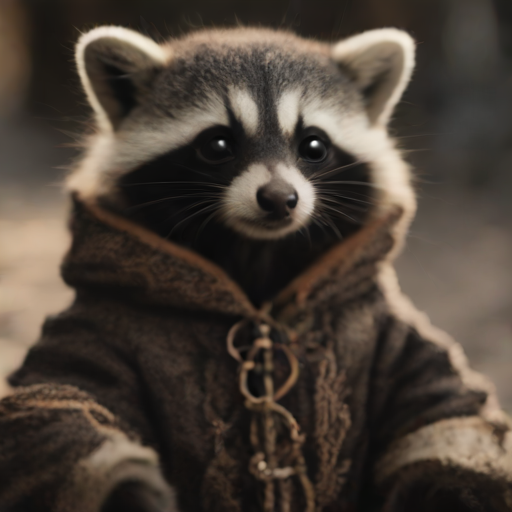

In [9]:
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")

prompt = "A cinematic shot of a baby racoon wearing an intricate italian priest robe."

image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
image

## Audioverarbeitung

[Ich bin ein Berliner](https://www.youtube.com/watch?v=hJNM0C-7lPk&t=15s)

In [10]:
# um dieses Beispiel auszuführen braucht man ffmpeg 
!sudo apt install ffmpeg -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following packages were automatically installed and are no longer required:
  linux-azure-6.5-cloud-tools-6.5.0-1025 linux-azure-6.5-tools-6.5.0-1025
  linux-cloud-tools-6.5.0-1025-azure linux-tools-6.5.0-1025-azure
  nvidia-firmware-550-server-550.144.03
Use 'sudo apt autoremove' to remove them.
The following additional packages will be installed:
  i965-va-driver intel-media-va-driver libaacs0 libaom3 libass9 libasyncns0
  libavc1394-0 libavcodec58 libavdevice58 libavfilter7 libavformat58
  libavutil56 libbdplus0 libblas3 libbluray2 libbs2b0 libcaca0 libcdio-cdda2
  libcdio-paranoia2 libcdio19 libchromaprint1 libcodec2-1.0 libdav1d5
  libdc1394-25 libdecor-0-0 libdecor-0-plugin-1-cairo libflac8 libflite1
  libgfortran5 libgme0 libgsm1 libiec61883-0 libigdgmm12 libjack-jackd2-0
  liblapack3 liblilv-0-0 libmfx1 libmp3lame0 libmpg123-0 libmysofa1 libnorm1
  libogg0 libopenal-data libopen

In [11]:

model_id = "openai/whisper-medium"

pipe = pipeline(
    "automatic-speech-recognition",
    model=model_id,
    chunk_length_s=30,
    batch_size=16,
    device = "cuda:0"
)


result = pipe("./data/speech.mp3")

result["text"]


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Device set to use cuda:0


ValueError: ffmpeg was not found but is required to load audio files from filename